<a href="https://colab.research.google.com/github/CEVP-7/P1-Clasificacion-de-Llantas-Da-adas-mediante-Reconocimiento-de-Textura/blob/main/CNN_Tires.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Clasificación de texturas de llantas con CNN Personalizada**

In [ ]:
pip install grad-cam opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 62.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=65dc7de00ed56801399f5f123e83ea1254d0d8a5a69684374c1b90aa4ad35522
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
import os
import copy
import zipfile
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageOps
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# Intenta importar Grad-CAM
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    GRAD_CAM_AVAILABLE = True
except ImportError:
    GRAD_CAM_AVAILABLE = False
    print("Grad-CAM no está disponible. Instale con: pip install grad-cam opencv-python")

In [ ]:
# -----------------------------
# 1. Reproducibilidad Estricta (Semillas)
# -----------------------------
SEED = 42
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)

In [ ]:
# -----------------------------
# 2. Configuración General y Switches
# -----------------------------
BATCH_SIZE = 32
LEARNING_RATE = 0.001
NUM_EPOCHS = 100
PATIENCE = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

USE_CUSTOM_PREPROCESS =
USE_AUGMENTATION = True

ZIP_PATH = '/content/drive/MyDrive/TireTextureImageRecognition.zip'
EXTRACT_PATH = '/content/dataset_tire'
TRAIN_DATA_DIR = os.path.join(EXTRACT_PATH, 'Tire Textures/training_data')
TEST_DATA_DIR = os.path.join(EXTRACT_PATH, 'Tire Textures/testing_data')

print(f"Dispositivo: {DEVICE} | Semilla: {SEED} | Custom Preprocess: {USE_CUSTOM_PREPROCESS}")

Dispositivo: cuda | Semilla: 42 | Custom Preprocess: True


In [ ]:
# -----------------------------
# 3. Montar Google Drive y descomprimir datos
# -----------------------------
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Drive montado.")
except ImportError:
    print("No estamos en Colab, omitiendo montaje.")

if os.path.exists(ZIP_PATH):
    if not os.path.exists(EXTRACT_PATH):
        print(f"Descomprimiendo {ZIP_PATH}...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(EXTRACT_PATH)
        print("Descompresión completada.")
else:
    raise FileNotFoundError(f"No se encontró el archivo {ZIP_PATH}")

Mounted at /content/drive
Drive montado.
Descomprimiendo /content/drive/MyDrive/TireTextureImageRecognition.zip...
Descompresión completada.


In [ ]:
# -----------------------------
# 4. Transformaciones Modulares
# -----------------------------
class HybridCLAHEBlackHat(object):
    def __init__(self, tile_grid=(8, 8), k_size=9, alpha=0.7, beta=0.3):
        self.clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=tile_grid)
        self.alpha = alpha
        self.beta = beta
        self.kernels = []
        base = np.zeros((k_size, k_size), dtype=np.uint8)
        cv2.line(base, (0, k_size//2), (k_size-1, k_size//2), 1, 1)
        for angle in [0, 45, 90, 135]:
            M = cv2.getRotationMatrix2D((k_size//2, k_size//2), angle, 1)
            k_rot = cv2.warpAffine(base, M, (k_size, k_size))
            _, k_rot = cv2.threshold(k_rot, 0.5, 1, cv2.THRESH_BINARY)
            self.kernels.append(k_rot.astype(np.uint8))

    def __call__(self, img_pil):
        img_np = np.array(img_pil.convert('L'))
        img_clahe = self.clahe.apply(img_np)
        max_bh = np.zeros_like(img_clahe)
        for k in self.kernels:
            bh = cv2.morphologyEx(img_clahe, cv2.MORPH_BLACKHAT, k)
            max_bh = np.maximum(max_bh, bh)
        img_combined = cv2.addWeighted(img_clahe, self.alpha, max_bh, self.beta, 0)
        img_final = cv2.normalize(img_combined, None, 0, 255, cv2.NORM_MINMAX)
        return Image.fromarray(img_final).convert('RGB')

class HistogramEqualization(object):
    def __call__(self, img):
        return ImageOps.equalize(img)

train_trans_list = [transforms.Resize((224, 224))]
val_test_trans_list = [transforms.Resize((224, 224))]

preprocess_module = HybridCLAHEBlackHat() if USE_CUSTOM_PREPROCESS else HistogramEqualization()
train_trans_list.append(preprocess_module)
val_test_trans_list.append(preprocess_module)

if USE_AUGMENTATION:
    train_trans_list.extend([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15)
    ])

to_tensor_norm = [
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
]
train_trans_list.extend(to_tensor_norm)
val_test_trans_list.extend(to_tensor_norm)

train_transforms = transforms.Compose(train_trans_list)
val_test_transforms = transforms.Compose(val_test_trans_list)

In [ ]:
# -----------------------------
# 5. DataLoaders e Índices Dinámicos
# -----------------------------
full_train_dataset = datasets.ImageFolder(root=TRAIN_DATA_DIR, transform=train_transforms)
targets = full_train_dataset.targets
class_names = full_train_dataset.classes

# Mapeo Dinámico de Clases
CRACKED_IDX = full_train_dataset.class_to_idx.get('cracked', 0)
NORMAL_IDX = full_train_dataset.class_to_idx.get('normal', 1)

print("\n--- MAPEO DE CLASES ---")
print("class_names:", class_names)
print("class_to_idx:", full_train_dataset.class_to_idx)
print(f"Index asignado -> CRACKED: {CRACKED_IDX} | NORMAL: {NORMAL_IDX}")
print("-----------------------\n")

train_idx, val_idx = train_test_split(
    np.arange(len(targets)),
    test_size=0.2,
    stratify=targets,
    random_state=SEED
)

train_dataset = Subset(full_train_dataset, train_idx)
val_full_dataset = datasets.ImageFolder(root=TRAIN_DATA_DIR, transform=val_test_transforms)
val_dataset = Subset(val_full_dataset, val_idx)
test_dataset = datasets.ImageFolder(root=TEST_DATA_DIR, transform=val_test_transforms) # Es ImageFolder

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


--- MAPEO DE CLASES ---
class_names: ['cracked', 'normal']
class_to_idx: {'cracked': 0, 'normal': 1}
Index asignado -> CRACKED: 0 | NORMAL: 1
-----------------------



In [ ]:
# -----------------------------
# 6. Definición de la Red Neuronal
# -----------------------------
class CustomTireCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 0
            nn.BatchNorm2d(32),                           # 1
            nn.Hardswish(),                               # 2
            nn.MaxPool2d(2),                              # 3

            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 4
            nn.BatchNorm2d(64),                           # 5
            nn.Hardswish(),                               # 6
            nn.MaxPool2d(2),                              # 7

            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 8
            nn.BatchNorm2d(128),                          # 9
            nn.Hardswish(),                               # 10
            nn.MaxPool2d(2),                              # 11

            nn.Conv2d(128, 256, kernel_size=3, padding=1),# 12 (Target Grad-CAM)
            nn.BatchNorm2d(256),                          # 13
            nn.Hardswish(),                               # 14
        )
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.Hardswish(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

model = CustomTireCNN(num_classes=len(class_names)).to(DEVICE)

In [ ]:
model

CustomTireCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Hardswish()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Hardswish()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Hardswish()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_

In [ ]:
# -----------------------------
# 7. Funciones de Entrenamiento (Orientado a F1-Score Dinámico)
# -----------------------------
train_labels = [targets[i] for i in train_idx]
class_counts = torch.bincount(torch.tensor(train_labels))
class_weights = len(train_labels) / (len(class_counts) * class_counts.float())
criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1_cracked': []}

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

def evaluate_with_f1(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    val_loss = total_loss / total
    val_acc = correct / total
    # Uso del CRACKED_IDX mapeado dinámicamente
    val_f1 = f1_score(y_true, y_pred, pos_label=CRACKED_IDX, zero_division=0)
    return val_loss, val_acc, val_f1

In [ ]:
# -----------------------------
# 8. Bucle de Entrenamiento (Early Stopping)
# -----------------------------
print("\n" + "="*50 + "\nENTRENAMIENTO DE LA CNN\n" + "="*50)
best_val_f1 = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
counter = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_f1 = evaluate_with_f1(model, val_loader, criterion, DEVICE)

    history['train_loss'].append(train_loss); history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)
    history['val_f1_cracked'].append(val_f1)

    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1_cracked: {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    if counter >= PATIENCE:
        print(f"Early stopping activado en época {epoch+1}")
        break

model.load_state_dict(best_model_wts)


ENTRENAMIENTO DE LA CNN
Epoch  1/100 | Train Loss: 0.6534 Acc: 0.6103 | Val Loss: 0.7139 Acc: 0.5461 F1_cracked: 0.0588
Epoch  2/100 | Train Loss: 0.5711 Acc: 0.7242 | Val Loss: 0.7872 Acc: 0.5887 F1_cracked: 0.2162
Epoch  3/100 | Train Loss: 0.5308 Acc: 0.7705 | Val Loss: 0.5008 Acc: 0.7943 F1_cracked: 0.7563
Epoch  4/100 | Train Loss: 0.5266 Acc: 0.7616 | Val Loss: 0.6206 Acc: 0.6099 F1_cracked: 0.6452
Epoch  5/100 | Train Loss: 0.4858 Acc: 0.7758 | Val Loss: 0.6159 Acc: 0.7021 F1_cracked: 0.5532
Epoch  6/100 | Train Loss: 0.4407 Acc: 0.8007 | Val Loss: 0.4378 Acc: 0.8227 F1_cracked: 0.7788
Epoch  7/100 | Train Loss: 0.4342 Acc: 0.8096 | Val Loss: 0.8815 Acc: 0.6241 F1_cracked: 0.6581
Epoch  8/100 | Train Loss: 0.4559 Acc: 0.7865 | Val Loss: 0.4711 Acc: 0.8085 F1_cracked: 0.8000
Epoch  9/100 | Train Loss: 0.4259 Acc: 0.8149 | Val Loss: 0.3820 Acc: 0.8582 F1_cracked: 0.8333
Epoch 10/100 | Train Loss: 0.3657 Acc: 0.8541 | Val Loss: 0.4580 Acc: 0.7872 F1_cracked: 0.7945
Epoch 11/100 | 

<All keys matched successfully>

In [ ]:
# -----------------------------
# 9. Calibración y Evaluación Final
# -----------------------------
print("\nCalibrando Umbral Óptimo en Validation Set...")
model.eval()
val_true, val_probs = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs.to(DEVICE))
        probs = F.softmax(outputs, dim=1)
        val_true.extend(labels.cpu().numpy())
        # Extraemos la probabilidad dinámica de ser Cracked
        val_probs.extend(probs[:, CRACKED_IDX].cpu().numpy())

best_threshold, best_calibrated_f1 = 0.5, 0.0
for th in np.arange(0.1, 0.9, 0.05):
    # Si la probabilidad de Cracked supera el umbral, asignamos CRACKED_IDX, sino NORMAL_IDX
    val_pred_th = np.where(np.array(val_probs) >= th, CRACKED_IDX, NORMAL_IDX)
    f1 = f1_score(val_true, val_pred_th, pos_label=CRACKED_IDX, zero_division=0)
    if f1 > best_calibrated_f1:
        best_calibrated_f1 = f1
        best_threshold = th

print(f"Umbral Óptimo Encontrado: {best_threshold:.2f} (Val F1-Cracked: {best_calibrated_f1:.4f})")

print("\nEvaluando en Test Set...")
test_true, test_probs = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs.to(DEVICE))
        probs = F.softmax(outputs, dim=1)
        test_true.extend(labels.cpu().numpy())
        test_probs.extend(probs[:, CRACKED_IDX].cpu().numpy())

test_true, test_probs = np.array(test_true), np.array(test_probs)
test_pred_calibrado = np.where(test_probs >= best_threshold, CRACKED_IDX, NORMAL_IDX)

print("\n" + "="*50)
print(f"REPORTE DE CLASIFICACIÓN (Test, Umbral: {best_threshold:.2f})")
print("="*50)
reporte_texto = classification_report(test_true, test_pred_calibrado, target_names=class_names, zero_division=0)
print(reporte_texto)
reporte_dict = classification_report(test_true, test_pred_calibrado, target_names=class_names, zero_division=0, output_dict=True)


Calibrando Umbral Óptimo en Validation Set...
Umbral Óptimo Encontrado: 0.60 (Val F1-Cracked: 0.8976)

Evaluando en Test Set...

REPORTE DE CLASIFICACIÓN (Test, Umbral: 0.60)
              precision    recall  f1-score   support

     cracked       0.90      0.55      0.68       210
      normal       0.52      0.89      0.66       115

    accuracy                           0.67       325
   macro avg       0.71      0.72      0.67       325
weighted avg       0.77      0.67      0.67       325



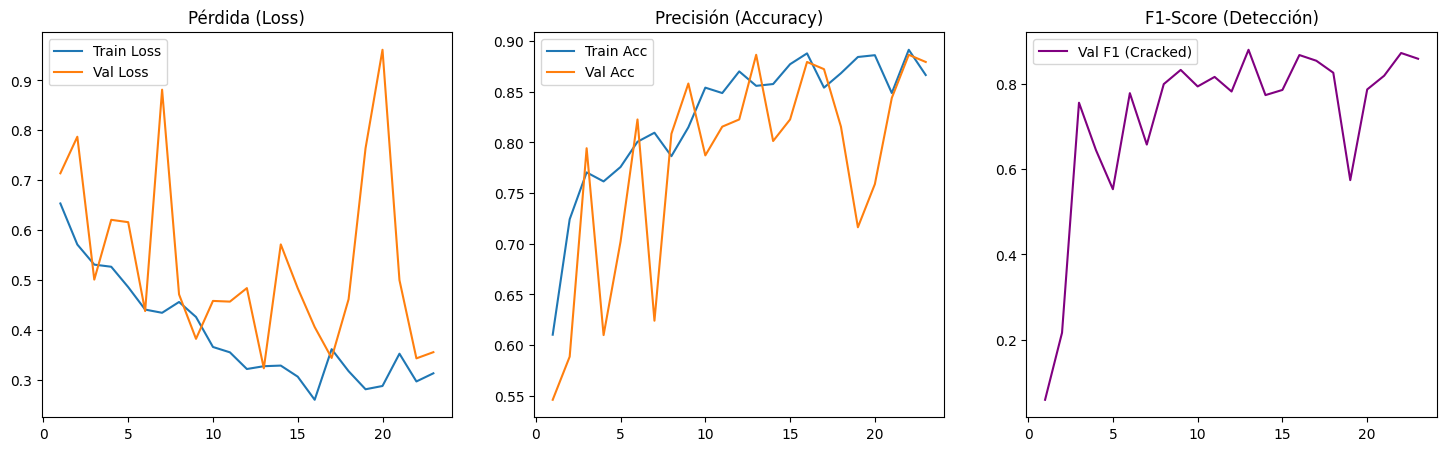

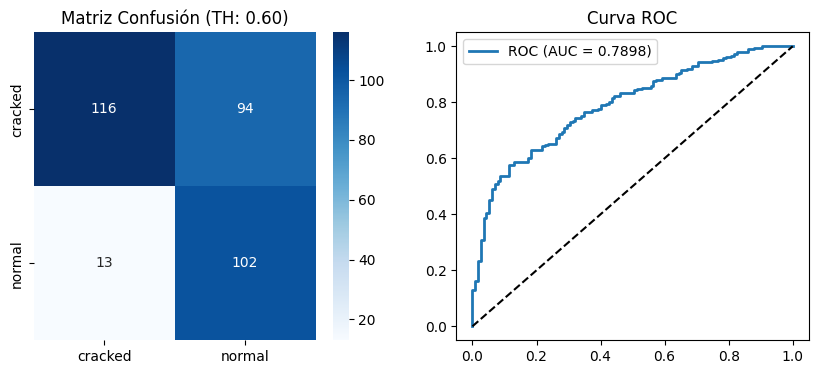


Modelo guardado exitosamente en 'cnn_custom_research.pth'


In [ ]:
# -----------------------------
# 10. Gráficas y Checkpoint
# -----------------------------
y_true_cracked = (test_true == CRACKED_IDX).astype(int)
auc = roc_auc_score(y_true_cracked, test_probs)
fpr, tpr, _ = roc_curve(y_true_cracked, test_probs)

test_precision_cracked = precision_score(test_true, test_pred_calibrado, pos_label=CRACKED_IDX, zero_division=0)
test_recall_cracked = recall_score(test_true, test_pred_calibrado, pos_label=CRACKED_IDX, zero_division=0)
test_f1_cracked = f1_score(test_true, test_pred_calibrado, pos_label=CRACKED_IDX, zero_division=0)
cm = confusion_matrix(test_true, test_pred_calibrado)

# Curvas de Entrenamiento
plt.figure(figsize=(18, 5))
epochs_total = range(1, len(history['train_loss']) + 1)
plt.subplot(1, 3, 1)
plt.plot(epochs_total, history['train_loss'], label='Train Loss')
plt.plot(epochs_total, history['val_loss'], label='Val Loss')
plt.title('Pérdida (Loss)'); plt.legend()
plt.subplot(1, 3, 2)
plt.plot(epochs_total, history['train_acc'], label='Train Acc')
plt.plot(epochs_total, history['val_acc'], label='Val Acc')
plt.title('Precisión (Accuracy)'); plt.legend()
plt.subplot(1, 3, 3)
plt.plot(epochs_total, history['val_f1_cracked'], label='Val F1 (Cracked)', color='purple')
plt.title('F1-Score (Detección)'); plt.legend()
plt.show()

# ROC y CM
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz Confusión (TH: {best_threshold:.2f})')
plt.subplot(1,2,2)
plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {auc:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.title('Curva ROC'); plt.legend()
plt.show()

# Checkpoint Documental Exhaustivo
checkpoint = {
    "model_state_dict": model.state_dict(),
    "model_state_note": "Pesos garantizados de la mejor época (F1-Score) antes de la calibración del umbral.",
    "model_name": "CustomTireCNN",
    "best_threshold": best_threshold,
    "class_to_idx": full_train_dataset.class_to_idx,
    "use_custom_preprocess": USE_CUSTOM_PREPROCESS,
    "use_augmentation": USE_AUGMENTATION,
    "seed": SEED,
    "hyperparameters": {
        "num_epochs_max": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
        "patience": PATIENCE
    },
    "metrics_validation": {
        "best_val_f1_uncalibrated": best_val_f1,
        "best_val_f1_calibrated": best_calibrated_f1
    },
    "metrics_test": {
        "test_auc": auc,
        "test_precision_cracked": test_precision_cracked,
        "test_recall_cracked": test_recall_cracked,
        "test_f1_cracked": test_f1_cracked
    },
    "history": history,
    "confusion_matrix": cm.tolist(),
    "classification_report": reporte_dict
}
torch.save(checkpoint, "cnn_custom_research.pth")
print("\nModelo guardado exitosamente en 'cnn_custom_research.pth'")


Generando auditoría visual 3vs3 con mapas de calor...


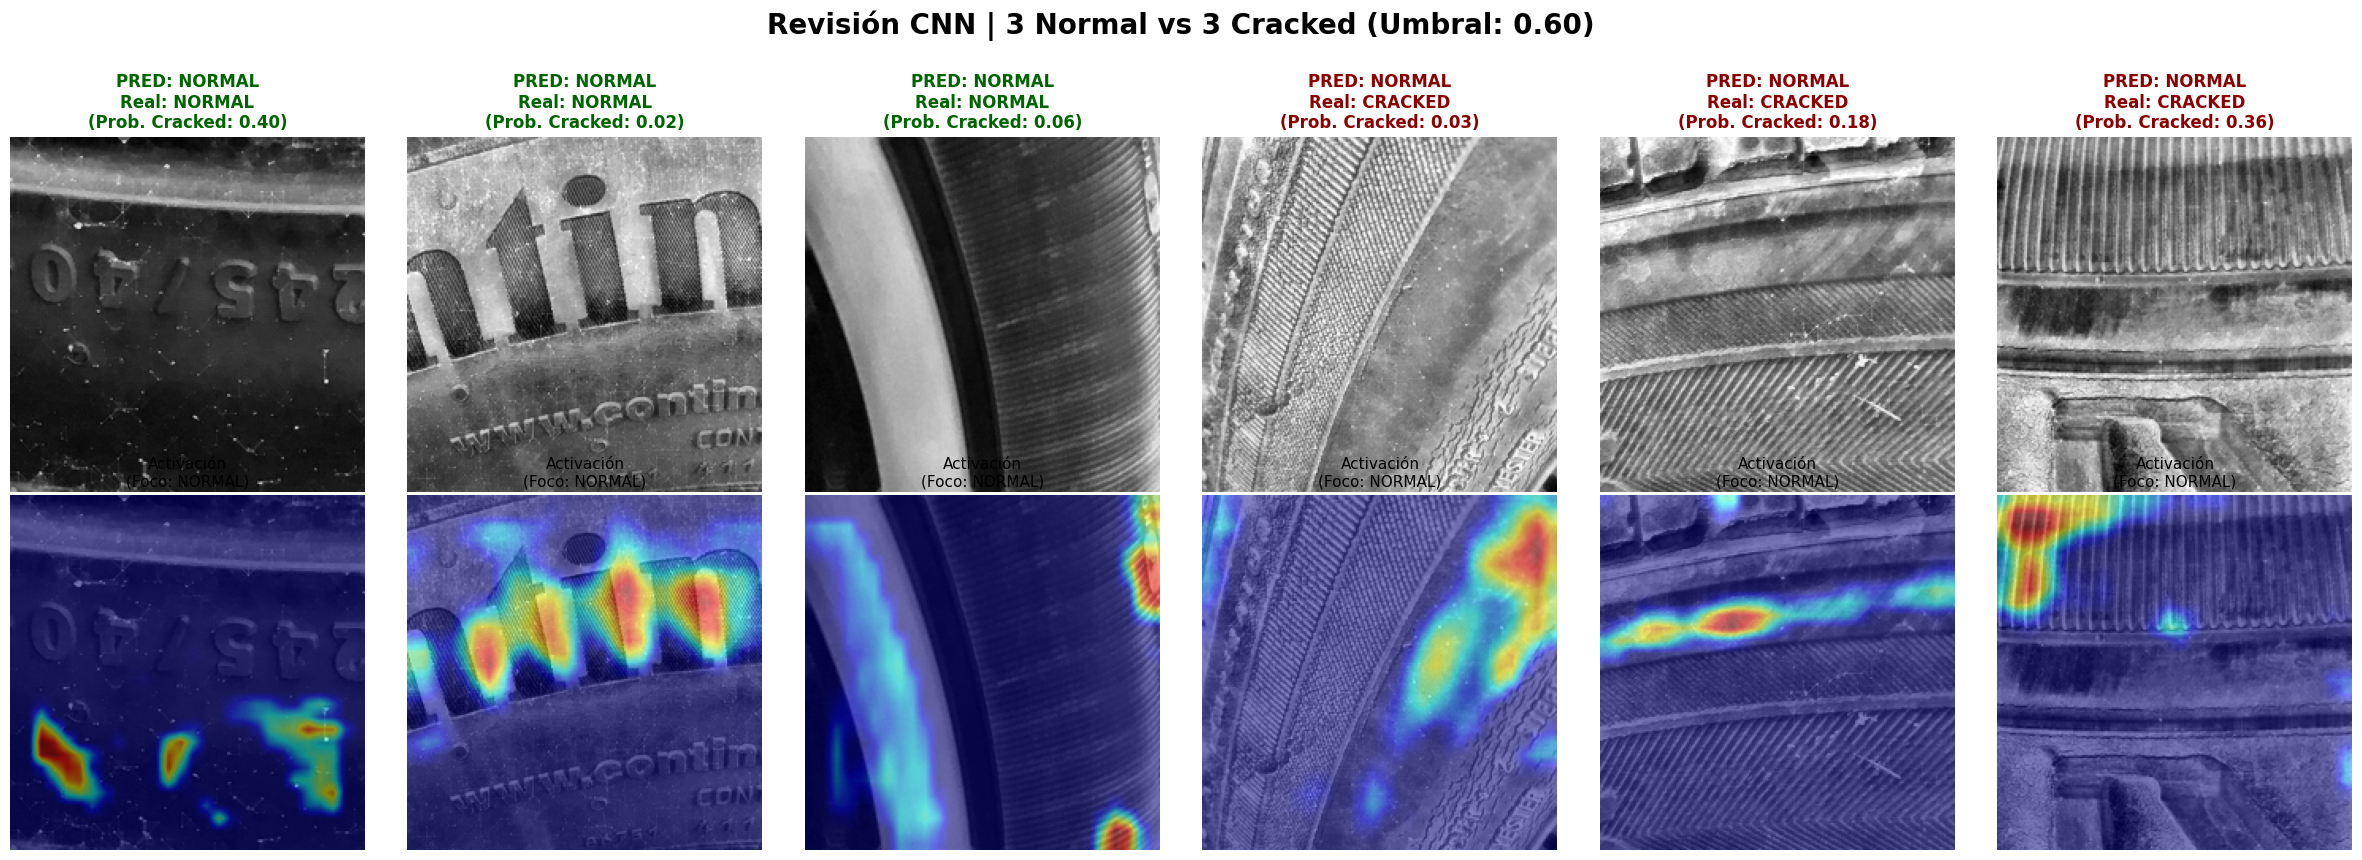


¡Script de CNN validado y finalizado!


In [ ]:
# -----------------------------
# 11. Auditoría Grad-CAM (3vs3 Aleatorio)
# -----------------------------
if GRAD_CAM_AVAILABLE:
    print("\nGenerando auditoría visual 3vs3 con mapas de calor...")

    idx_real_cracked = np.where(test_true == CRACKED_IDX)[0]
    idx_real_normal = np.where(test_true == NORMAL_IDX)[0]

    sample_cracked = random.sample(list(idx_real_cracked), min(3, len(idx_real_cracked)))
    sample_normal = random.sample(list(idx_real_normal), min(3, len(idx_real_normal)))
    muestras_totales = sample_normal + sample_cracked

    target_layers = [model.features[12]]
    cam = GradCAM(model=model, target_layers=target_layers)

    tensor_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    fig, axes = plt.subplots(2, 6, figsize=(24, 9))
    fig.suptitle(f'Revisión CNN | 3 Normal vs 3 Cracked (Umbral: {best_threshold:.2f})', fontsize=20, fontweight='bold')

    for i, idx in enumerate(muestras_totales):
        # Corrección: test_dataset es un ImageFolder, por lo que usamos .samples directamente
        img_path, real_label = test_dataset.samples[idx]
        img_pil = Image.open(img_path).convert('RGB')

        pred_label = test_pred_calibrado[idx]
        prob_cracked = test_probs[idx]

        real_name = class_names[real_label].upper()
        pred_name = class_names[pred_label].upper()
        color_titulo = 'darkgreen' if real_label == pred_label else 'darkred'

        img_resized = img_pil.resize((224, 224))
        img_preprocesada = preprocess_module(img_resized)

        input_tensor = tensor_transform(img_preprocesada).unsqueeze(0).to(DEVICE)
        img_float_np = np.float32(img_preprocesada) / 255.0

        targets = [ClassifierOutputTarget(pred_label)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
        cam_image = show_cam_on_image(img_float_np, grayscale_cam, use_rgb=True)

        axes[0, i].imshow(img_preprocesada)
        texto_titulo = f"PRED: {pred_name}\nReal: {real_name}\n(Prob. Cracked: {prob_cracked:.2f})"
        axes[0, i].set_title(texto_titulo, color=color_titulo, fontsize=12, fontweight='bold')
        axes[0, i].axis('off')
        if i == 2:
            axes[0, i].spines['right'].set_linewidth(3); axes[0, i].spines['right'].set_color('black')

        axes[1, i].imshow(cam_image)
        axes[1, i].set_title(f"Activación\n(Foco: {pred_name})", fontsize=11)
        axes[1, i].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig('cnn_auditoria_predicciones.png', dpi=300)
    plt.show()

print("\n¡Script de CNN validado y finalizado!")